In [113]:
import numpy as np
import bacco

import sys
sys.path.append("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

import matplotlib.pyplot as plt

In [114]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [139]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial', 'fiducial_new_ICs']

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

_snap = 264
zoom = {}

for i in range(len(name_list)):
    base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/"+name_list[i]+"/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(_snap,_snap), dm_file="snapdir_{:03d}/snapshot_{:03d}".format(_snap,_snap),\
			    sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, use_ids=False, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(_snap,_snap), numpart=4320**3)

### Load the Halo Selection ###
xmatch = {}
for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264, name=name_list[i])


2026-05-12 18:18:01,168 bacco.sims : Initialising simulation Default
2026-05-12 18:18:01,169 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264
2026-05-12 18:18:01,171 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264
2026-05-12 18:18:01,175 bacco.sims : ...done in 0.0072 s
2026-05-12 18:18:01,176 bacco.sims : Initialising simulation Default
2026-05-12 18:18:01,176 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-05-12 18:18:01,178 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-05-12 18:18:01,181 bacco.sims : ...done in 0.00513 s
2026-05-12 18:18:01,181 bacco.sims : Initialising simulation Default
2026-05-12 18:18:01,182 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/snapdir_264/snapshot_264


In [140]:
def get_contamination_fraction(zoom, xmatch):

    # The high-resolution mass will be sum of the DM, gas, stars and BH mass
    hd_mass = (zoom.fof['halo_mfof_type'][:,0] + zoom.fof['halo_mfof_type'][:,1] + zoom.fof['halo_mfof_type'][:,4] + zoom.fof['halo_mfof_type'][:,5])[xmatch['ind']]

    # The low resolution mass will be the sum of the low-res DM particles
    lr_mass = zoom.fof['halo_mfof_type'][:,2][xmatch['ind']] + zoom.fof['halo_mfof_type'][:,3][xmatch['ind']]

    return lr_mass / (hd_mass + lr_mass)    

def get_binned_contamination_fraction(zoom, xmatch, mass_bins):
    # Compute masses
    hd_mass = 1e10 * (zoom.fof['halo_mfof_type'][:,0] + zoom.fof['halo_mfof_type'][:,1] +
               zoom.fof['halo_mfof_type'][:,4] + zoom.fof['halo_mfof_type'][:,5])[xmatch['ind']]
    lr_mass = 1e10 * (zoom.fof['halo_mfof_type'][:,2][xmatch['ind']] +
               zoom.fof['halo_mfof_type'][:,3][xmatch['ind']])
    
    total_mass = hd_mass + lr_mass
    contamination = lr_mass / total_mass

    # Bin the halos by total_mass
    bin_indices = np.digitize(total_mass, mass_bins) - 1  # bins are 0-indexed
    binned_fraction = []
    bin_centers = 0.5 * (mass_bins[:-1] + mass_bins[1:])

    for i in range(len(mass_bins) - 1):
        in_bin = bin_indices == i
        if np.any(in_bin):
            binned_fraction.append(np.mean(contamination[in_bin]))
        else:
            binned_fraction.append(np.nan)  # or 0, or skip

    return bin_centers, np.array(binned_fraction)

In [149]:
f_cont = []
m_halo = []
for i in range(len(name_list)-1):
    f_cont.append(get_contamination_fraction(zoom[name_list[i]], xmatch[name_list[i]]))
    m_halo.append(1e10 * zoom[name_list[i]].fof['halo_m200c'][xmatch[name_list[i]]['ind']])

f_cont = np.ndarray.flatten(np.array(f_cont))
m_halo = np.ndarray.flatten(np.array(m_halo))

# High-res simulation
f_cont_hd = get_contamination_fraction(zoom['fiducial_new_ICs'], xmatch['fiducial_new_ICs'])
m_halo_hd = 1e10 * zoom['fiducial_new_ICs'].fof['halo_mfof'][xmatch['fiducial_new_ICs']['ind']]

2026-05-12 18:20:15,428 bacco.sims : Reading 142791 items for Group_M_Crit200
2026-05-12 18:20:15,442 bacco.sims : Reading 143520 items for Group_M_Crit200
2026-05-12 18:20:15,452 bacco.sims : Reading 146601 items for Group_M_Crit200
2026-05-12 18:20:15,462 bacco.sims : Reading 141432 items for Group_M_Crit200
2026-05-12 18:20:15,686 bacco.sims : Reading 145271 items for Group_M_Crit200
2026-05-12 18:20:15,929 bacco.sims : Reading 145320 items for Group_M_Crit200
2026-05-12 18:20:16,108 bacco.sims : Reading 146135 items for Group_M_Crit200
2026-05-12 18:20:16,321 bacco.sims : Reading 139876 items for Group_M_Crit200
2026-05-12 18:20:16,546 bacco.sims : Reading 142352 items for Group_M_Crit200
2026-05-12 18:20:16,776 bacco.sims : Reading 144105 items for Group_M_Crit200
2026-05-12 18:20:16,949 bacco.sims : Reading 135036 items for Group_M_Crit200
2026-05-12 18:20:17,204 bacco.sims : Reading 139921 items for Group_M_Crit200
2026-05-12 18:20:17,446 bacco.sims : Reading 141667 items for Gr

In [150]:
mass_bins = np.logspace(10, 15, 20)  # Example mass bins from 10^10 to 10^15 Msun
f_binned = {}

for i in range(len(name_list)):
    f_binned[name_list[i]] = get_binned_contamination_fraction(zoom[name_list[i]], xmatch[name_list[i]], mass_bins)

In [151]:
print(len(f_cont[f_cont == 0]) / len(f_cont))
print(len(f_cont[f_cont <= 1e-3]) / len(f_cont))
print(len(f_cont[f_cont <= 1e-2]) / len(f_cont))

0.795104196403083
0.842706251784185
0.9103625463888096


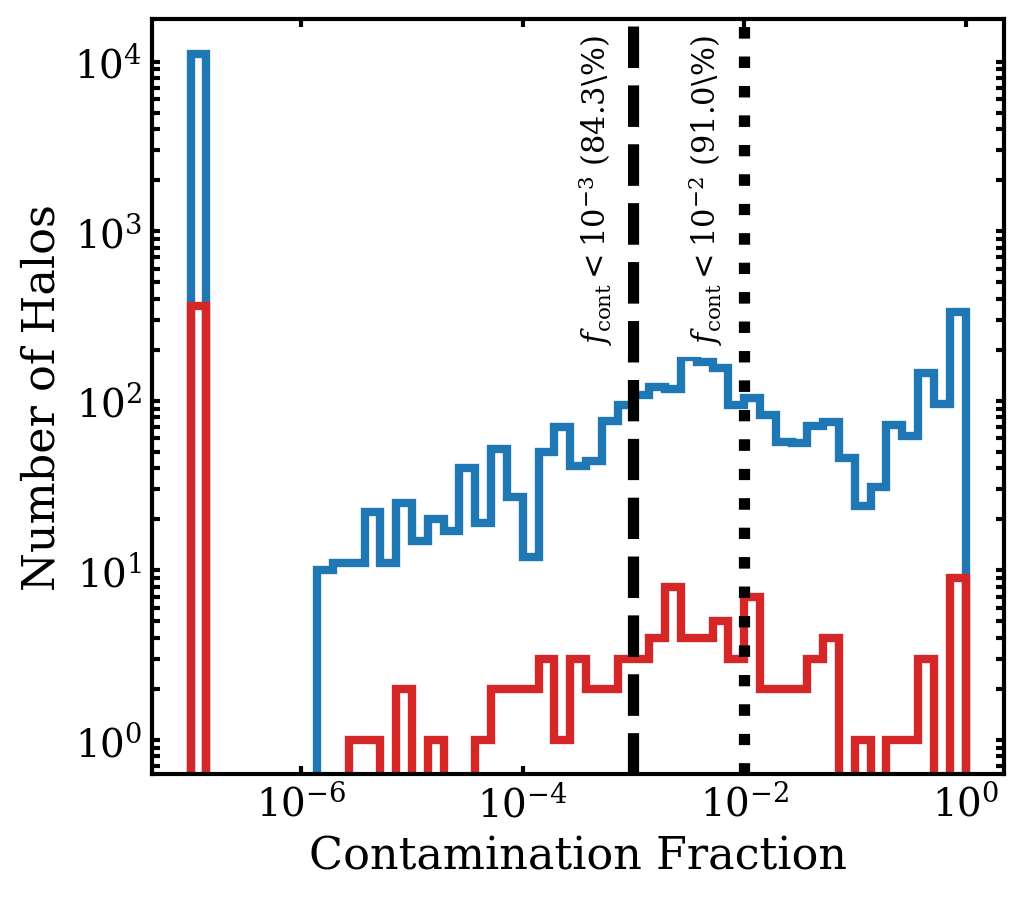

In [152]:
fig, ax = plt.subplots(figsize=(5.5,5), dpi=200)

ax.set_xscale('log')

ax.hist(f_cont+1e-7, bins=np.logspace(-7,0,50), density=False, log=True, histtype='step', color='C0', lw=3);
ax.hist(f_cont_hd+1e-7, bins=np.logspace(-7,0,50), density=False, log=True, histtype='step', color='C3', lw=3);

ax.axvline(1e-3, color='k', ls='--', lw=4)
ax.axvline(1e-2, color='k', ls=':', lw=4)

ax.set_ylabel("Number of Halos", fontsize=16)
ax.set_xlabel("Contamination Fraction", fontsize=16)

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, width=1.5, length=3, labelsize=14)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Adjust thickness as desired

# Calculate fractions
frac_1e3 = np.sum(f_cont < 1e-3) / len(f_cont) * 100
frac_1e2 = np.sum(f_cont < 1e-2) / len(f_cont) * 100

# Plot vertical lines
ax.axvline(1e-3, color='k', ls='--', lw=4)
ax.axvline(1e-2, color='k', ls=':', lw=4)

# Add labels
ax.text(3e-4, ax.get_ylim()[1]*0.1, 
        fr'$f_{{\rm cont}} < 10^{{-3}}$ ({frac_1e3:.1f}\%)', 
        rotation=90, va='center', ha='left', fontsize=11, color='k', backgroundcolor='w')

ax.text(3e-3, ax.get_ylim()[1]*0.1, 
        fr'$f_{{\rm cont}} < 10^{{-2}}$ ({frac_1e2:.1f}\%)', 
        rotation=90, va='center', ha='left', fontsize=11, color='k', backgroundcolor='w')

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/validation/contamination_histogram.pdf", bbox_inches='tight')

/tmp/ipykernel_300652/2977968698.py:13: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax.set_ylim(0,1)


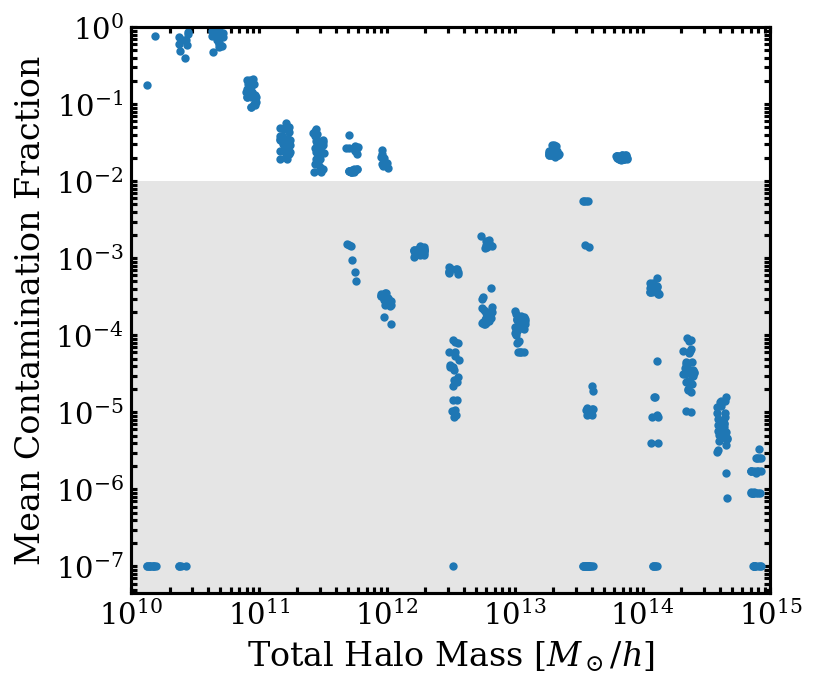

In [153]:
fig, ax = plt.subplots(figsize=(5.5,5), dpi=150)

ax.set_xscale('log')
ax.set_yscale('log')
for i in range(len(name_list)-1):
    shift = np.random.uniform(-0.1, 0.1, size=f_binned[name_list[i]][0].shape)  # Small random shift
    ax.plot(f_binned[name_list[i]][0] * (1 + shift), f_binned[name_list[i]][1]+1e-7, color='C0', lw=3, label=name_list[i], ls='', marker='o', ms=3)

ax.plot(f_binned['fiducial'][0], f_binned['fiducial'][1], color='C0', lw=3, label='Fiducial', ls='', marker='o', ms=3)
ax.fill_between(np.logspace(9,16,10), -0.5, 1e-2, color='gray', alpha=0.2, ec=None)

ax.set_xlim(1e10, 1e15)
ax.set_ylim(0,1)

ax.set_xlabel("Total Halo Mass [$M_\odot/h$]", fontsize=16)
ax.set_ylabel("Mean Contamination Fraction", fontsize=16)

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, width=1.5, length=3, labelsize=14)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Adjust thickness as desired

In [154]:
m_median = np.median(zoom['fiducial'].lowres_dm['mass']) * 1e10

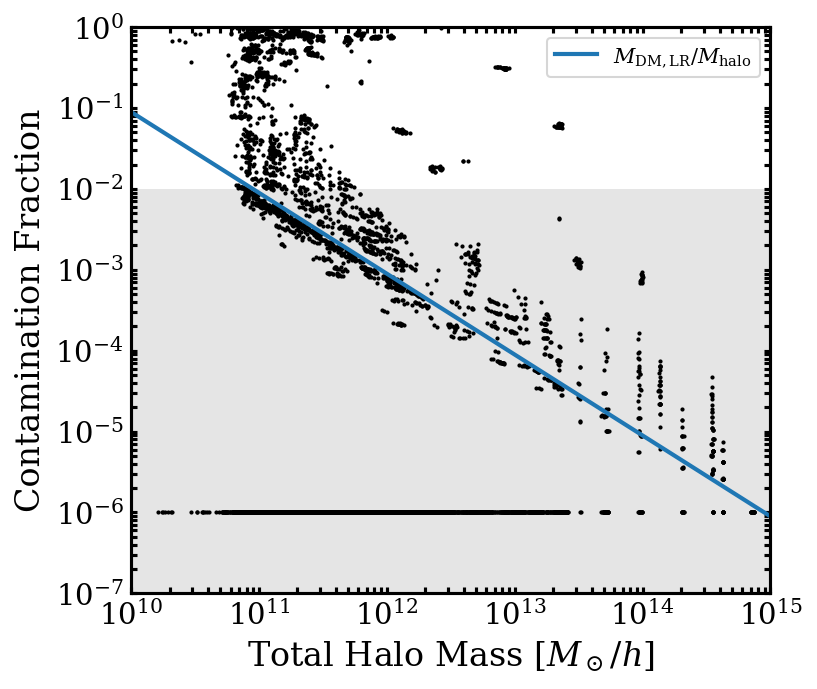

In [156]:
fig, ax = plt.subplots(figsize=(5.5,5), dpi=150)

ax.set_xscale('log')
ax.set_yscale('log')

m_array = np.logspace(9,16,10)
ax.fill_between(m_array, -0.5, 1e-2, color='gray', alpha=0.2, ec=None)
ax.scatter(m_halo, f_cont + 1e-6, s=1, color="k")
# ax.scatter(m_halo_hd, f_cont_hd + 1e-6, s=1, color="C3", label="High-res")
ax.plot(m_array, m_median/m_array, color='C0', lw=2, label=r"$M_\mathrm{DM,LR}/M_\mathrm{halo}$")

ax.set_xlim(1e10, 1e15)
ax.set_ylim(1e-7,1)

ax.set_xlabel("Total Halo Mass [$M_\odot/h$]", fontsize=16)
ax.set_ylabel("Contamination Fraction", fontsize=16)

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, width=1.5, length=3, labelsize=14)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Adjust thickness as desired

ax.legend(loc="upper right")

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/validation/contamination_fraction_Mh.pdf", bbox_inches='tight')